# Rust rewrite: results

The pipeline in [`../src`](../src) is the same millisecond loop as the Python tree in `../../original`: re-reference, forward Butterworth 250-5000 Hz, 4 ms reverse filter, threshold crossings and spike-band power. This notebook checks that it gives the same answer as the Python path we kept after week 2, and shows where the time goes.

Every timing is **milliseconds of compute per second of data** on this machine (4-core Intel Xeon, Sapphire Rapids, AVX-512). Under 1000 is real time. Synthetic data is 200 windows (0.2 s) of Gaussian noise with planted spikes; the real recording is the first 10 s of `NSP1_aligned.ns6` (128 electrodes).

Three paths appear in the graphs:

- **original loop**: the project's first implementation (`original/src/utils.py`), as a reference point only;
- **Python kept path**: `OptimizedProcessor` after week 2 (block re-reference, AVX-512 forward filter, reverse filter as one multiply), single thread;
- **Rust**: this crate, one thread, and with four lanes (one per core).


In [1]:
%matplotlib inline
import contextlib
import io
import json
import os
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.abspath("../../original/src"))

import neurostream
from optimizations import OptimizedProcessor, _apply_fir
from utils import build_filter, rereference_data

SAMPLE_RATE = 30_000
SAMPLES_PER_MS = 30
GROUP_SIZE = 64
DATA = "../../data/NSP1_aligned.ns6"
PARAMS = "../../data/NSP1_aligned_params.json"
SECONDS = 10

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
COLORS = {"original loop": "0.6", "Python kept path": "tab:blue", "Rust, 1 thread": "tab:orange", "Rust, 4 lanes": "tab:red"}


def quiet(fn):
    with contextlib.redirect_stdout(io.StringIO()):
        return fn()


print("neurostream", neurostream.__version__, "-", neurostream.build_target())


neurostream 0.1.0 - x86_64 with AVX-512 (eight f64 per instruction)


## 1. Same answer

Rust and the Python kept path on the same 10 s of the recording, with the LRR parameter file the earlier notebooks use. The waveform overlay is one electrode for 30 ms; the histogram is every filtered sample's difference, in units of the recording (0.25 µV).

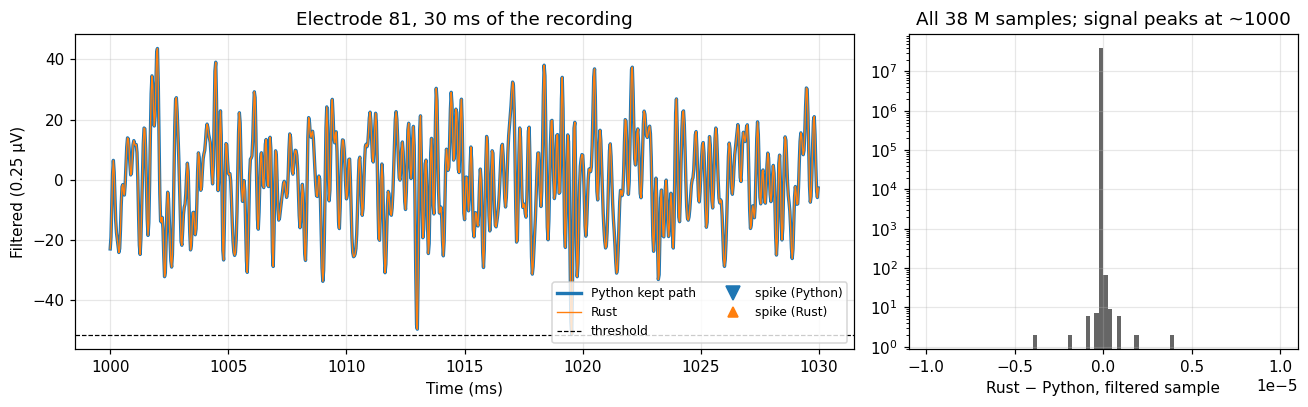

spikes: Python 26611, Rust 26611, bins that differ 0
filtered: max |difference| 3.8e-06 on a signal up to 1055; spike-band power max |difference| 1.1e-05 dB


In [2]:
P = json.load(open(PARAMS))
reref = np.asarray(P["rereference_parameters"], dtype=np.float64)
thresholds = np.asarray(P["thresholds"], dtype=np.float64).ravel()
groups = [list(g) for g in P["reref_groups"]]
raw, rate = neurostream.read_ns6(DATA, max_samples=SECONDS * SAMPLE_RATE)   # (n_samples, n_channels) int16

rust1 = neurostream.Processor(reref, thresholds, groups, threads=1)
t0 = time.perf_counter(); rs = rust1.process_recording(raw); t_rust1 = time.perf_counter() - t0
py_proc = quiet(lambda: OptimizedProcessor(128, reref, thresholds, groups, use_gpu=False))
t0 = time.perf_counter(); py = py_proc.process_recording(raw.T); t_py = time.perf_counter() - t0

ok = ~np.isnan(py.filtered)
diff = (rs["filtered"] - py.filtered)[ok]
AGREE = dict(
    spikes_py=int(py.spikes.sum()), spikes_rust=int(rs["spikes"].sum()),
    spike_mismatch=int((rs["spikes"] != py.spikes).sum()),
    filt_max=float(np.abs(diff).max()), filt_scale=float(np.abs(py.filtered[ok]).max()),
    sbp_max=float(np.nanmax(np.abs(rs["spike_band_power"] - py.spike_band_power))),
)
REAL_TIMES = {"Python kept path": t_py / SECONDS * 1000, "Rust, 1 thread": t_rust1 / SECONDS * 1000}

ch, t0_ms, span_ms = 81, 1000, 30
s = slice(t0_ms * SAMPLES_PER_MS, (t0_ms + span_ms) * SAMPLES_PER_MS)
tt = np.arange(s.start, s.stop) / SAMPLES_PER_MS
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [2, 1]})
ax = axes[0]
ax.plot(tt, py.filtered[ch, s], color=COLORS["Python kept path"], lw=2.2, label="Python kept path")
ax.plot(tt, rs["filtered"][ch, s], color=COLORS["Rust, 1 thread"], lw=0.9, label="Rust")
ax.axhline(thresholds[ch], color="k", ls="--", lw=0.8, label="threshold")
spk_py = np.flatnonzero(py.spikes[ch, t0_ms:t0_ms + span_ms]) + t0_ms
spk_rs = np.flatnonzero(rs["spikes"][ch, t0_ms:t0_ms + span_ms]) + t0_ms
ax.plot(spk_py + 0.5, np.full(spk_py.size, thresholds[ch] * 1.6), "v", color=COLORS["Python kept path"], ms=9, label="spike (Python)")
ax.plot(spk_rs + 0.5, np.full(spk_rs.size, thresholds[ch] * 1.6), "^", color=COLORS["Rust, 1 thread"], ms=6, label="spike (Rust)")
ax.set_xlabel("Time (ms)"); ax.set_ylabel("Filtered (0.25 µV)"); ax.set_title(f"Electrode {ch}, {span_ms} ms of the recording")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax = axes[1]
ax.hist(diff, bins=np.linspace(-1e-5, 1e-5, 81), color="0.4")
ax.set_yscale("log"); ax.set_xlabel("Rust − Python, filtered sample"); ax.set_title("All 38 M samples; signal peaks at ~1000")
fig.tight_layout(); plt.show()

print(f"spikes: Python {AGREE['spikes_py']}, Rust {AGREE['spikes_rust']}, bins that differ {AGREE['spike_mismatch']}")
print(f"filtered: max |difference| {AGREE['filt_max']:.1e} on a signal up to {AGREE['filt_scale']:.0f}; spike-band power max |difference| {AGREE['sbp_max']:.1e} dB")


## 2. Where the time goes

Steady state: the processor is already built, the output arrays already exist, and only the per-millisecond work is timed. Rust is timed by `neurostream-bench` (built from `../src/bin/bench.rs`); the two Python paths are timed in this kernel the same way `optimization_results.ipynb` does. 200 windows, median of 3 runs. The stage split is a second, instrumented run with the clock stopped between stages, so its stage sum is a little above the plain total.

In [3]:
def make_recording(n_channels, n_ms, seed=1, spike_every_ms=10, spike_amp=-500.0):
    rng = np.random.default_rng(seed)
    raw = rng.normal(scale=20.0, size=(n_channels, n_ms * SAMPLES_PER_MS))
    groups = [list(range(s, min(s + GROUP_SIZE, n_channels))) for s in range(0, n_channels, GROUP_SIZE)]
    params = np.zeros((n_channels, n_channels))
    for g in groups:
        params[np.ix_(g, g)] = 1.0 / len(g)
    for ms in range(8, n_ms, spike_every_ms):
        start = ms * SAMPLES_PER_MS + 12
        raw[(ms // spike_every_ms) % n_channels, start:start + 2] = spike_amp
    return raw, params, np.full((n_channels, 1), -120.0), groups


def run_original(raw, params, thr):
    n_ch, n_win = raw.shape[0], raw.shape[1] // SAMPLES_PER_MS
    lag = int(round(0.004 * SAMPLE_RATE))
    filter_func, sos, zi, rev_win, rev_zi = quiet(lambda: build_filter(
        n_channels=n_ch, but_low=250, but_high=5000, causal=False, acausal_filter_type="fir", acausal_filter_lag=lag, fs=SAMPLE_RATE))
    spikes = np.zeros((n_ch, n_win), dtype=np.int16); sbp = np.zeros((n_ch, n_win), dtype=np.float32)
    rev_buffer = np.full((n_ch, lag + SAMPLES_PER_MS), np.nan, dtype=np.float32); filt = np.zeros((n_ch, SAMPLES_PER_MS), dtype=np.float32)
    thr = np.asarray(thr).reshape(-1, 1)
    t0 = time.perf_counter()
    for i in range(n_win):
        chunk = rereference_data(raw[:, i * SAMPLES_PER_MS:(i + 1) * SAMPLES_PER_MS], params)
        filter_func(chunk, filt, rev_buffer, sos, zi, rev_win, rev_zi)
        spikes[:, i] = np.any((filt[:, 1:] < thr) & (filt[:, :-1] >= thr), axis=1)
        sbp[:, i] = (10 * np.log10(np.square(filt))).mean(axis=1)
    return time.perf_counter() - t0


def kept_path_steady(n_channels, n_ms, repeats=3, stages=False):
    data, params, thr, gl = make_recording(n_channels, n_ms + 20)
    proc = quiet(lambda: OptimizedProcessor(n_channels, params, thr, gl, use_gpu=False, per_array_threads=False, per_channel_threads=False))
    quiet(lambda: proc.process_recording(data[:, :SAMPLES_PER_MS * 20]))
    data = data[:, SAMPLES_PER_MS * 20:]
    spw = proc.samples_per_window
    filt_out = np.zeros((n_channels, n_ms * spw), dtype=np.float32); reref_out = np.zeros_like(filt_out)
    sbp_out = np.zeros((n_channels, n_ms), dtype=np.float32); spk_out = np.zeros((n_channels, n_ms), dtype=np.int16)
    keys = ("reref", "forward", "reverse", "features", "write")

    def once():
        acc = dict.fromkeys(keys, 0.0)
        for i in range(n_ms):
            chunk = data[:, i * SAMPLES_PER_MS:(i + 1) * SAMPLES_PER_MS]
            if not stages:
                proc._compute_window(chunk)
            else:
                t0 = time.perf_counter(); np.copyto(proc._raw_buf, chunk); proc._apply_reref()
                t1 = time.perf_counter(); buf = proc.rev_buffer; buf[:, :-spw] = buf[:, spw:]; proc._forward_sos(proc._reref_window, buf[:, -spw:])
                t2 = time.perf_counter(); proc._leading_nans = 0; _apply_fir(buf, proc._rev_win, spw, proc.filt_buffer, proc._fir_band, 0)
                t3 = time.perf_counter(); proc._features_all()
                t4 = time.perf_counter()
            o = i * spw
            reref_out[:, o:o + spw] = proc._reref_window; filt_out[:, o:o + spw] = proc.filt_buffer
            sbp_out[:, i] = proc._sbp_win; spk_out[:, i] = proc._spikes_win
            if stages:
                t5 = time.perf_counter()
                for k, v in zip(keys, (t1 - t0, t2 - t1, t3 - t2, t4 - t3, t5 - t4)):
                    acc[k] += v
        return acc

    once()
    neural = n_ms / 1000.0
    totals, splits = [], []
    for _ in range(repeats):
        t0 = time.perf_counter(); acc = once(); totals.append((time.perf_counter() - t0) / neural * 1000)
        splits.append({k: acc[k] / neural * 1000 for k in keys})
    proc.close()
    split = {k: float(np.median([s[k] for s in splits])) for k in keys} if stages else None
    return float(np.median(totals)), split


def original_steady(n_channels, n_ms, repeats=3):
    data, params, thr, _ = make_recording(n_channels, n_ms)
    return float(np.median([run_original(data, params, thr) / (n_ms / 1000.0) * 1000 for _ in range(repeats)]))


def rust_bench(args):
    bench = os.path.abspath("../target/release/neurostream-bench")
    if not os.path.exists(bench):
        subprocess.run(["cargo", "build", "--release"], cwd="..", check=True, capture_output=True)
    out = subprocess.run([bench] + args, cwd="..", check=True, capture_output=True, text=True).stdout
    return [json.loads(line) for line in out.splitlines() if line.startswith("{")]


CHANNELS = (64, 256, 1024, 2048)
N_MS = 200
STEADY = {name: {} for name in COLORS}
STAGES = {}
for n in CHANNELS:
    STEADY["original loop"][n] = original_steady(n, N_MS)
    STEADY["Python kept path"][n], _ = kept_path_steady(n, N_MS)
    _, STAGES[("Python kept path", n)] = kept_path_steady(n, N_MS, stages=True)
for row in rust_bench(["synthetic", "--channels", ",".join(map(str, CHANNELS)), "--threads", "1,4", "--windows", str(N_MS), "--repeats", "3"]):
    name = "Rust, 1 thread" if row["threads"] == 1 else "Rust, 4 lanes"
    STEADY[name][row["channels"]] = row["total_ms_per_s"]
    if row["stages_ms_per_s"]:
        STAGES[(name, row["channels"])] = row["stages_ms_per_s"]

print(f"{'channels':>9}" + "".join(f"{k:>18}" for k in STEADY))
for n in CHANNELS:
    print(f"{n:9d}" + "".join(f"{STEADY[k][n]:18.0f}" for k in STEADY))


 channels     original loop  Python kept path    Rust, 1 thread     Rust, 4 lanes
       64               195                47                17                17
      256               766               167                70                69
     1024              4052               646               362               179
     2048             13446              1435               839               472


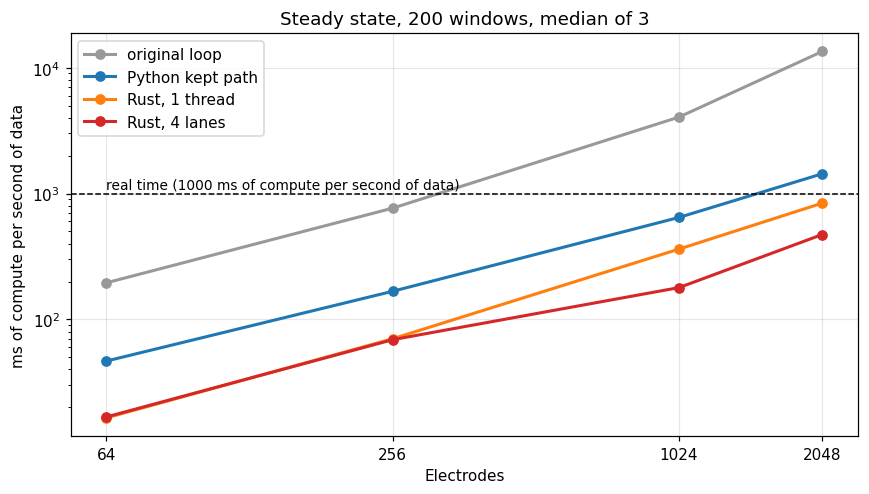

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for name, series in STEADY.items():
    ax.plot(CHANNELS, [series[n] for n in CHANNELS], "o-", color=COLORS[name], label=name, lw=2)
ax.axhline(1000, color="k", ls="--", lw=1); ax.text(CHANNELS[0], 1080, "real time (1000 ms of compute per second of data)", fontsize=9)
ax.set_xscale("log", base=2); ax.set_yscale("log"); ax.set_xticks(CHANNELS); ax.set_xticklabels(CHANNELS)
ax.set_xlabel("Electrodes"); ax.set_ylabel("ms of compute per second of data"); ax.set_title("Steady state, 200 windows, median of 3")
ax.legend(); fig.tight_layout(); plt.show()


### Stage split

The same five stages in both trees, timed with the clock stopped between them. "write" is copying the millisecond's results into the recording-sized output arrays.

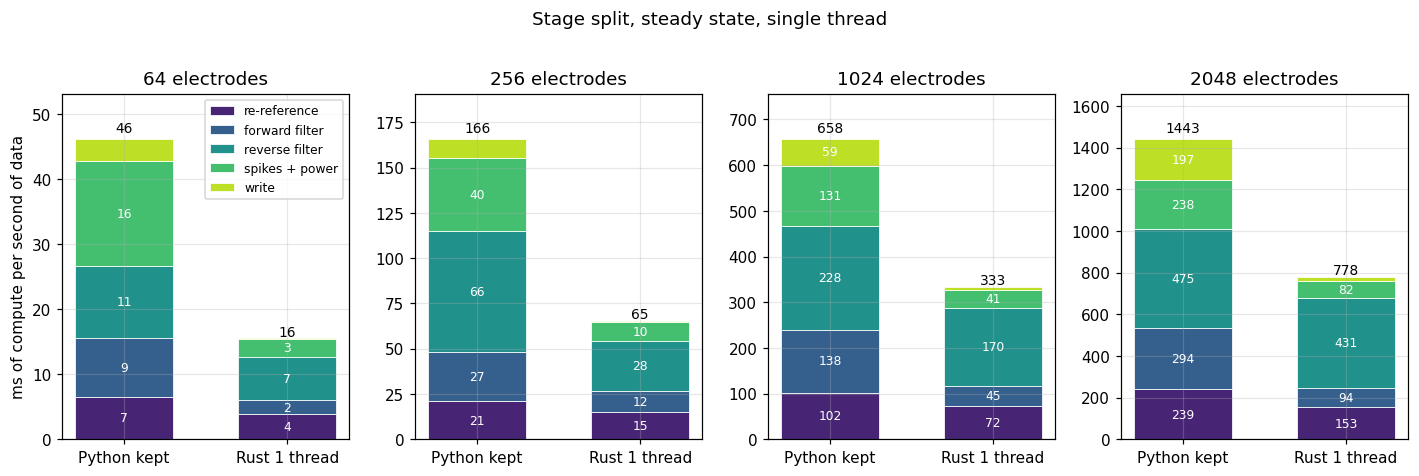

In [5]:
keys = ("reref", "forward", "reverse", "features", "write")
labels = {"reref": "re-reference", "forward": "forward filter", "reverse": "reverse filter", "features": "spikes + power", "write": "write"}
stage_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 5))
fig, axes = plt.subplots(1, len(CHANNELS), figsize=(13, 4.2))
for ax, n in zip(axes, CHANNELS):
    for xi, name in enumerate(("Python kept path", "Rust, 1 thread")):
        bottom = 0.0
        for k, c in zip(keys, stage_colors):
            v = STAGES[(name, n)][k]
            ax.bar(xi, v, 0.6, bottom=bottom, color=c, edgecolor="white", lw=0.5, label=labels[k] if (n == CHANNELS[0] and xi == 0) else None)
            if v > 0.08 * sum(STAGES[(name, n)].values()):
                ax.text(xi, bottom + v / 2, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white")
            bottom += v
        ax.text(xi, bottom * 1.02, f"{bottom:.0f}", ha="center", fontsize=9)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Python kept", "Rust 1 thread"]); ax.set_title(f"{n} electrodes")
    ax.set_ylim(0, max(sum(STAGES[(nm, n)].values()) for nm in ("Python kept path", "Rust, 1 thread")) * 1.15)
axes[0].set_ylabel("ms of compute per second of data"); axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Stage split, steady state, single thread", y=1.02); fig.tight_layout(); plt.show()


### Lanes

Each lane owns a block of electrodes and all of its filter state, so four lanes run one millisecond on four cores with nothing shared. 64 electrodes is one re-reference group, so it stays on one lane.

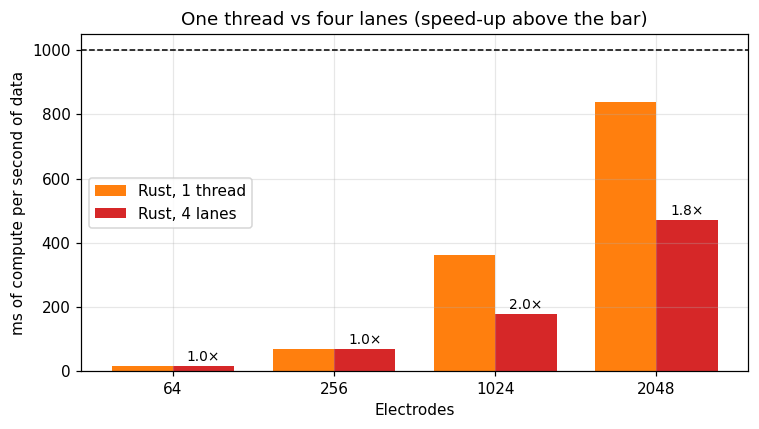

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(CHANNELS)); w = 0.38
one = [STEADY["Rust, 1 thread"][n] for n in CHANNELS]; four = [STEADY["Rust, 4 lanes"][n] for n in CHANNELS]
ax.bar(x - w / 2, one, w, color=COLORS["Rust, 1 thread"], label="Rust, 1 thread")
ax.bar(x + w / 2, four, w, color=COLORS["Rust, 4 lanes"], label="Rust, 4 lanes")
for xi, a, b in zip(x, one, four):
    ax.text(xi + w / 2, b + 15, f"{a / b:.1f}×", ha="center", fontsize=9)
ax.axhline(1000, color="k", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(CHANNELS); ax.set_xlabel("Electrodes"); ax.set_ylabel("ms of compute per second of data")
ax.set_title("One thread vs four lanes (speed-up above the bar)"); ax.legend(); fig.tight_layout(); plt.show()


## 3. The real recording

The first 10 s of `NSP1_aligned.ns6`, 128 electrodes, LRR parameters. Whole-recording wall time of each path, including the output arrays, divided by the 10 s of data. The LRR weights for this file link electrodes across both groups, so Rust uses one lane here regardless of `threads`.

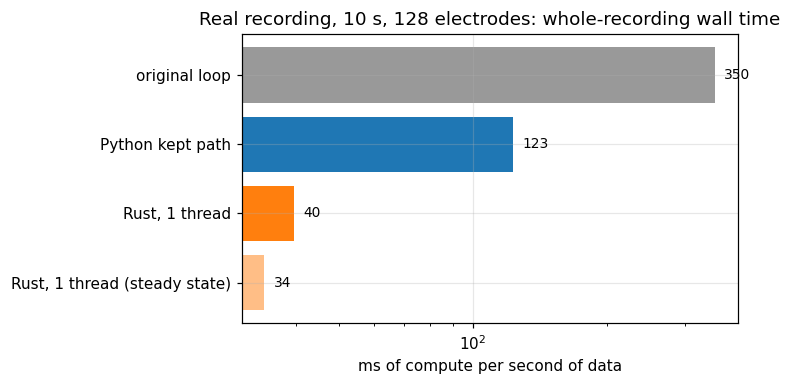

In [7]:
data_bench = rust_bench(["ns6", "--file", os.path.abspath(DATA), "--params", os.path.abspath(PARAMS), "--seconds", str(SECONDS), "--threads", "1"])
real_times = {"original loop": None, "Python kept path": REAL_TIMES["Python kept path"], "Rust, 1 thread": REAL_TIMES["Rust, 1 thread"]}
real_times["original loop"] = run_original(raw.T.astype(np.float64), reref, thresholds) / SECONDS * 1000
rust_steady_real = data_bench[0]["total_ms_per_s"]

fig, ax = plt.subplots(figsize=(7, 3.6))
names = list(real_times)
vals = [real_times[n] for n in names]
bars = ax.barh(names, vals, color=[COLORS[n] for n in names])
ax.barh(["Rust, 1 thread (steady state)"], [rust_steady_real], color=COLORS["Rust, 1 thread"], alpha=0.5)
for b, v in zip(list(bars) + list(ax.containers[-1]), vals + [rust_steady_real]):
    ax.text(v * 1.05, b.get_y() + b.get_height() / 2, f"{v:.0f}", va="center", fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("ms of compute per second of data"); ax.invert_yaxis()
ax.set_title(f"Real recording, {SECONDS} s, 128 electrodes: whole-recording wall time"); fig.tight_layout(); plt.show()


## Summary

In [8]:
print("Agreement with the Python kept path (10 s, 128 electrodes, LRR):")
print(f"  spikes {AGREE['spikes_rust']} vs {AGREE['spikes_py']}, bins that differ: {AGREE['spike_mismatch']}")
print(f"  filtered max |difference| {AGREE['filt_max']:.1e} (float32 rounding), spike-band power {AGREE['sbp_max']:.1e} dB")
print()
print("Steady state, ms of compute per second of data (real time = 1000):")
print(f"{'electrodes':>10} {'original':>10} {'Python kept':>12} {'Rust 1t':>9} {'Rust 4 lanes':>13}")
for n in CHANNELS:
    print(f"{n:10d} {STEADY['original loop'][n]:10.0f} {STEADY['Python kept path'][n]:12.0f} {STEADY['Rust, 1 thread'][n]:9.0f} {STEADY['Rust, 4 lanes'][n]:13.0f}")
n = 1024
print()
print(f"Largest stage at {n} electrodes: Python kept path -> {max(STAGES[('Python kept path', n)], key=STAGES[('Python kept path', n)].get)}, "
      f"Rust -> {max(STAGES[('Rust, 1 thread', n)], key=STAGES[('Rust, 1 thread', n)].get)}")


Agreement with the Python kept path (10 s, 128 electrodes, LRR):
  spikes 26611 vs 26611, bins that differ: 0
  filtered max |difference| 3.8e-06 (float32 rounding), spike-band power 1.1e-05 dB

Steady state, ms of compute per second of data (real time = 1000):
electrodes   original  Python kept   Rust 1t  Rust 4 lanes
        64        195           47        17            17
       256        766          167        70            69
      1024       4052          646       362           179
      2048      13446         1435       839           472

Largest stage at 1024 electrodes: Python kept path -> reverse, Rust -> reverse
